<a href="https://colab.research.google.com/github/SHARANYA-216/Face-detection/blob/main/Face%20detection%20using%20OpenCV%20with%20Haar%20Cascade%20Classifiers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Face Detection with OpenCV


```
Objectives : The main objective of this project:

1. Detect one or more faces in a given image.

2. Highlight them visually by drawing rectangles around the detected regions.

3. Demonstrate how traditional computer vision techniques can perform facial detection in real-time without deep learning.
```

# How does it works:
1. Image Input
2. Preprocessing
3. Face Detection ( Haar Cascade )
4. Face Highlighting
5. Result Display



# Why this project is Important

1. Facial recognition systems (security, authentication)

2. Emotion and behavior analysis

3. Attendance and surveillance systems

4. Photo organization (like Google Photos or iPhone’s gallery)

This project helps you understand how machines can perceive human faces


In [ ]:
# install the library and dependencies
!pip install opencv-python-headless matplotlib --quiet


In [ ]:
import cv2
import matplotlib.pyplot as plt
import urllib.request
import numpy as np
import os

In [ ]:
# Download Haar cascade
cascade_url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
cascade_path = "haarcascade_frontalface_default.xml"
if not os.path.exists(cascade_path):
    urllib.request.urlretrieve(cascade_url, cascade_path)

face_cascade = cv2.CascadeClassifier(cascade_path)

In [ ]:
# Load the images with the URl
img_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"

try:
    req = urllib.request.Request(
        img_url,
        data=None,
        headers={
            'User-Agent': 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.36'
        }
    )

    resp = urllib.request.urlopen(req)
    img_data = np.asarray(bytearray(resp.read()), dtype="uint8")
    img = cv2.imdecode(img_data, cv2.IMREAD_COLOR)

    if img is None:
        print(f"Error: Could not decode image from {img_url}. Check the URL and image format.")
    else:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(30, 30),
            flags=cv2.CASCADE_SCALE_IMAGE
        )
        print(f"Detected {len(faces)} face(s)")
except Exception as e:
    print(f"An error occurred: {e}")




Detected 1 face(s)


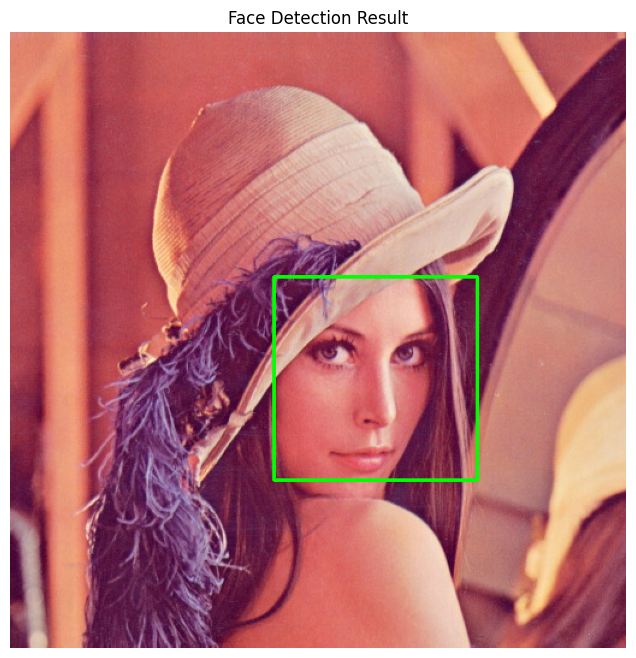

In [ ]:
# Draw the reactangles around the faces
for (x,y,w,h) in faces:
  cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)
# Convert the BGR to RGB for the matplotlib display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


# Display the result
plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Face Detection Result")
plt.show()